# Análisis bivariado — ClassicModels


## Celda de conexión a la BD

**Qué hace:** abre una conexión a MySQL (`classicmodels`) y carga cada tabla principal en un DataFrame de pandas.

**Cómo funciona:**
1. `mysql.connector.connect(...)` se conecta al contenedor Docker en `127.0.0.1:3307` (mapeado en `docker-compose.yml` porque el 3306 local ya estaba ocupado).
2. `pd.read_sql(...)` ejecuta un `SELECT *` por tabla y guarda el resultado en memoria.
3. Al final se cierra la conexión para no dejar el motor ocupado.

**Para qué sirve:** tener los datos listos en Python para graficar con seaborn/matplotlib (análisis bivariado) sin volver a escribir SQL en cada celda.

**Requisito previo:** la BD debe estar corriendo (`docker compose up -d`).

In [45]:
import mysql.connector
import pandas as pd

# IMPORTANTE: port=3307 (ver docker-compose.yml). Sin esto Python usa 3306 y falla.
connection = mysql.connector.connect(
    host="127.0.0.1",
    port=3307,
    user="root",
    password="root",
    database="classicmodels",
)

print("Conexión OK →", connection.server_host)

df_customers = pd.read_sql("SELECT * FROM customers", connection)
df_employees = pd.read_sql("SELECT * FROM employees", connection)
df_offices = pd.read_sql("SELECT * FROM offices", connection)
df_orders = pd.read_sql("SELECT * FROM orders", connection)
df_orderdetails = pd.read_sql("SELECT * FROM orderdetails", connection)
df_payments = pd.read_sql("SELECT * FROM payments", connection)
df_products = pd.read_sql("SELECT * FROM products", connection)
df_productlines = pd.read_sql("SELECT * FROM productlines", connection)

print("Tablas cargadas:")
for nombre, df in [
    ("customers", df_customers),
    ("employees", df_employees),
    ("offices", df_offices),
    ("orders", df_orders),
    ("orderdetails", df_orderdetails),
    ("payments", df_payments),
    ("products", df_products),
    ("productlines", df_productlines),
]:
    print(f"  - {nombre}: {df.shape[0]} filas × {df.shape[1]} columnas")

connection.close()
print("Conexión cerrada")

Conexión OK → 127.0.0.1
Tablas cargadas:
  - customers: 122 filas × 13 columnas
  - employees: 23 filas × 8 columnas
  - offices: 7 filas × 9 columnas
  - orders: 326 filas × 7 columnas
  - orderdetails: 2996 filas × 5 columnas
  - payments: 273 filas × 4 columnas
  - products: 110 filas × 9 columnas
  - productlines: 7 filas × 4 columnas
Conexión cerrada


/var/folders/26/ln42rh4x0jq01r21hbkqvx3m0000gn/T/ipykernel_6248/3533005456.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_customers = pd.read_sql("SELECT * FROM customers", connection)
/var/folders/26/ln42rh4x0jq01r21hbkqvx3m0000gn/T/ipykernel_6248/3533005456.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_employees = pd.read_sql("SELECT * FROM employees", connection)
/var/folders/26/ln42rh4x0jq01r21hbkqvx3m0000gn/T/ipykernel_6248/3533005456.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_offices = 

## Exploración inicial / Hipótesis preliminares
_En customers estoy viendo que puedo agrupar con country y creditLimit. puede que haya una relación como que quizá le dan más crédito a personas de cierto país mientras que a otros no.

En employee puedo ver que quizá algunos empleados tengan asignados más clientes que otros y si es así. 

En office la verdad no veo mucha cosa interesante más que country.

En order podría ver cuántas órdenes hay por cliente y a qué cliente se le demora menos en hacer el ship. por ejemplo puede que haya algún cliente que repetitivamente haya menos tiempo entre orderdate y shippeddate y puede que estos clientes sean de un país en específico tremendooo.

En orderdetails podría unirlo con order yd arme cuenta qué clientes compran más en terminos de priceEach*quantityOrdered. Y quién sabe, si le meto mucha lógica podría saber si hay alguna relación entre qué tanto compra el cliente con qué tan rápido se le hace el envío.

En payments la verdad no sabría qué hacer quizá podría también darme cuenta si entre más amount tienen en sus payments, más rápido les llega el envío

En products podría preguntarme si la quantityInStock es proporcional a cómo se vende ese producto.

En product line podria preguntarme cuál es la linea a la que más le compran

En customers estoy viendo que puedo agrupar con country y creditLimit. puede que haya una relación como que quizá le dan más crédito a personas de cierto país mientras que a otros no.

En employee puedo ver que quizá algunos empleados tengan asignados más clientes que otros y si es así.

---

## Análisis bivariado 1

**Pregunta:** ¿Hay alguna relación entre el tiempo que transcurre entre `orderDate` y `shippedDate` y el país del cliente?

**Variables:**
- `dias_envio` (numérica, calculada): `shippedDate - orderDate` en días
- `country` (categórica): país del cliente

**Gráfico:** boxplot (país vs días de envío)

**Preparación:** unir `orders` con `customers` por `customerNumber`, calcular `dias_envio` y excluir pedidos sin `shippedDate` (aún no enviados).

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Unir pedidos con el país del cliente
df_biv1 = pd.merge(
    df_orders,
    df_customers[["customerNumber", "country"]],
    on="customerNumber",
    how="inner",
)

# Asegurar que las fechas sean datetime
df_biv1["orderDate"] = pd.to_datetime(df_biv1["orderDate"])
df_biv1["shippedDate"] = pd.to_datetime(df_biv1["shippedDate"])

# Variable calculada: días entre pedido y envío
df_biv1["dias_envio"] = (df_biv1["shippedDate"] - df_biv1["orderDate"]).dt.days

# Solo pedidos que ya se enviaron (tienen shippedDate)
df_biv1 = df_biv1.dropna(subset=["dias_envio"]).copy()

print("Pedidos con envío:", len(df_biv1))
print("Países distintos:", df_biv1["country"].nunique())
df_biv1[["orderNumber", "country", "orderDate", "shippedDate", "dias_envio"]].head(10)

Pedidos con envío: 312
Países distintos: 22


,orderNumber,country,orderDate,shippedDate,dias_envio
0,10100,USA,2003-01-06,2003-01-10,4.0
1,10101,Germany,2003-01-09,2003-01-11,2.0
2,10102,USA,2003-01-10,2003-01-14,4.0
3,10103,Norway,2003-01-29,2003-02-02,4.0
4,10104,Spain,2003-01-31,2003-02-01,1.0
5,10105,Denmark,2003-02-11,2003-02-12,1.0
6,10106,Italy,2003-02-17,2003-02-21,4.0
7,10107,USA,2003-02-24,2003-02-26,2.0
8,10108,Philippines,2003-03-03,2003-03-08,5.0
9,10109,USA,2003-03-10,2003-03-11,1.0


In [48]:
# Resumen numérico por país (para apoyarte al interpretar el gráfico)
resumen_pais = (
    df_biv1.groupby("country")["dias_envio"]
    .agg(pedidos="count", mediana="median", promedio="mean", minimo="min", maximo="max")
    .sort_values("mediana")
)
resumen_pais

,pedidos,mediana,promedio,minimo,maximo
country,,,,,
Belgium,6,1.5,2.000000,1.0,5.0
Austria,7,2.0,2.857143,2.0,5.0
Denmark,7,2.0,2.428571,1.0,6.0
Switzerland,2,2.0,2.000000,2.0,2.0
Singapore,9,2.0,9.111111,1.0,65.0
New Zealand,14,2.5,2.642857,1.0,6.0
Canada,7,3.0,3.571429,2.0,5.0
Finland,9,3.0,3.222222,1.0,6.0
Hong Kong,2,3.0,3.000000,1.0,5.0


### Limpieza de atípicos solo en Singapore

**Por qué (solo Singapore y no todo el país):**
En el boxplot original, Singapore mostraba un valor extremo de `dias_envio` que distorsionaba la escala vertical y dificultaba comparar el resto de países. No eliminamos Singapore completo porque el país sí aporta pedidos válidos; solo quitamos el/los puntos atípicos **dentro** de ese país.

**Método:** regla del IQR aplicada **únicamente** a las filas con `country == "Singapore"`:
- \(Q1\) = percentil 25, \(Q3\) = percentil 75, \(IQR = Q3 - Q1\)
- Se conserva lo que está entre \(Q1 - 1.5·IQR\) y \(Q3 + 1.5·IQR\)
- Los demás países se dejan igual

Así el gráfico sigue incluyendo Singapore, pero sin ese outlier que ensuciaba la comparación.

Singapore: Q1=1.0, Q3=4.0, IQR=3.0
Límites IQR: [-3.5, 8.5]
Atípicos eliminados en Singapore: 1


,orderNumber,country,orderDate,shippedDate,dias_envio
65,10165,Singapore,2003-10-22,2003-12-26,65.0


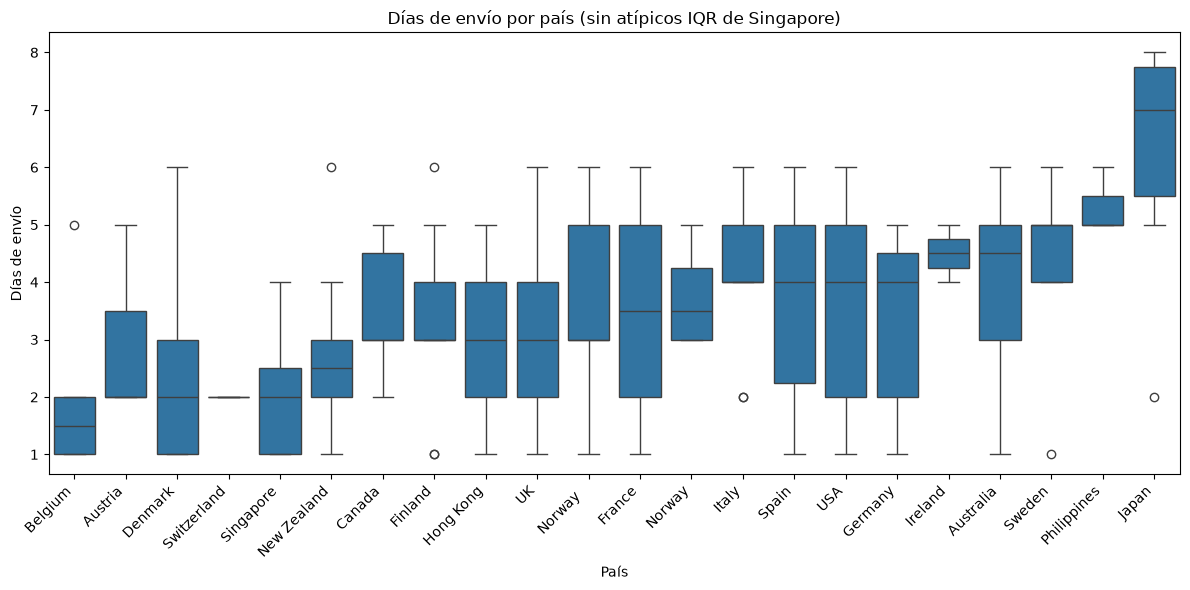

,pedidos,mediana,promedio,minimo,maximo
country,,,,,
Belgium,6,1.5,2.000000,1.0,5.0
Austria,7,2.0,2.857143,2.0,5.0
Denmark,7,2.0,2.428571,1.0,6.0
Switzerland,2,2.0,2.000000,2.0,2.0
Singapore,8,2.0,2.125000,1.0,4.0
New Zealand,14,2.5,2.642857,1.0,6.0
Canada,7,3.0,3.571429,2.0,5.0
Finland,9,3.0,3.222222,1.0,6.0
Hong Kong,2,3.0,3.000000,1.0,5.0


In [49]:
# Separar Singapore del resto
sg = df_biv1[df_biv1["country"] == "Singapore"].copy()
otros = df_biv1[df_biv1["country"] != "Singapore"].copy()

# IQR solo dentro de Singapore
q1 = sg["dias_envio"].quantile(0.25)
q3 = sg["dias_envio"].quantile(0.75)
iqr = q3 - q1
limite_inf = q1 - 1.5 * iqr
limite_sup = q3 + 1.5 * iqr

atipicos_sg = sg[~sg["dias_envio"].between(limite_inf, limite_sup)]
sg_limpio = sg[sg["dias_envio"].between(limite_inf, limite_sup)]

print(f"Singapore: Q1={q1:.1f}, Q3={q3:.1f}, IQR={iqr:.1f}")
print(f"Límites IQR: [{limite_inf:.1f}, {limite_sup:.1f}]")
print(f"Atípicos eliminados en Singapore: {len(atipicos_sg)}")
if len(atipicos_sg) > 0:
    display(atipicos_sg[["orderNumber", "country", "orderDate", "shippedDate", "dias_envio"]])

df_biv1_sin_atipicos_sg = pd.concat([otros, sg_limpio], ignore_index=True)

resumen_limpio = (
    df_biv1_sin_atipicos_sg.groupby("country")["dias_envio"]
    .agg(pedidos="count", mediana="median", promedio="mean", minimo="min", maximo="max")
    .sort_values("mediana")
)

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_biv1_sin_atipicos_sg,
    x="country",
    y="dias_envio",
    order=resumen_limpio.index.tolist(),
)
plt.title("Días de envío por país (sin atípicos IQR de Singapore)")
plt.xlabel("País")
plt.ylabel("Días de envío")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

resumen_limpio

### Interpretación

- ¿Qué países tienen la mediana más baja / más alta de días de envío?
- ¿Hay países con mucha dispersión (cajas altas o muchos puntos atípicos)?
- ¿Te parece que hay relación entre país y tiempo de envío, o se ven parecidos?

**Tu interpretación:**

> Primero que todo tengo que decir que se tuvo que eliminar un dato atípico que tenía Singapo\ore, pues tenía un envío que había tardado 60 días en hacerse. Tras esto, podemos observar los diagramas de caja. Claramente sí hay una variación de las medianas, pues hay unos paises que tienen envíos rápidos entre 1 y 3 días. Pero en el otro extremo destaca Japón, quien su mediana de envío está claramente por encima del resto. De hecho, singapore sin el dato atípico se comporta como uno de los paises con envío rápido.

> Parece que el país del cliente sí está asociado, no es una relación perfecta pero puede influir la logísitca, distancia, etc. 


---

## Análisis bivariado 2

**Pregunta:** ¿Hay alguna relación entre el monto comprado y el tiempo que transcurre entre `orderDate` y `shippedDate`?

**Variables:**
- `monto_pedido` (numérica, calculada): suma de `priceEach * quantityOrdered` por pedido (`orderdetails`)
- `dias_envio` (numérica, calculada): `shippedDate - orderDate` en días (`orders`)

**Gráfico:** scatter plot (monto vs días de envío)

**Preparación:** agregar el monto por `orderNumber` en `orderdetails`, unir con `orders`, calcular `dias_envio` y quedarse solo con pedidos ya enviados.

In [50]:
# Monto total por pedido
df_montos = df_orderdetails.copy()
df_montos["line_total"] = df_montos["priceEach"] * df_montos["quantityOrdered"]

monto_por_pedido = (
    df_montos.groupby("orderNumber", as_index=False)["line_total"]
    .sum()
    .rename(columns={"line_total": "monto_pedido"})
)

# Unir con órdenes y calcular días de envío
df_biv2 = pd.merge(df_orders, monto_por_pedido, on="orderNumber", how="inner")
df_biv2["orderDate"] = pd.to_datetime(df_biv2["orderDate"])
df_biv2["shippedDate"] = pd.to_datetime(df_biv2["shippedDate"])
df_biv2["dias_envio"] = (df_biv2["shippedDate"] - df_biv2["orderDate"]).dt.days
df_biv2 = df_biv2.dropna(subset=["dias_envio"]).copy()

print("Pedidos usados:", len(df_biv2))
df_biv2[["orderNumber", "monto_pedido", "orderDate", "shippedDate", "dias_envio"]].head(10)

Pedidos usados: 312


,orderNumber,monto_pedido,orderDate,shippedDate,dias_envio
0,10100,10223.83,2003-01-06,2003-01-10,4.0
1,10101,10549.01,2003-01-09,2003-01-11,2.0
2,10102,5494.78,2003-01-10,2003-01-14,4.0
3,10103,50218.95,2003-01-29,2003-02-02,4.0
4,10104,40206.20,2003-01-31,2003-02-01,1.0
5,10105,53959.21,2003-02-11,2003-02-12,1.0
6,10106,52151.81,2003-02-17,2003-02-21,4.0
7,10107,22292.62,2003-02-24,2003-02-26,2.0
8,10108,51001.22,2003-03-03,2003-03-08,5.0
9,10109,25833.14,2003-03-10,2003-03-11,1.0


In [51]:
# Resumen numérico de apoyo (tú interpretas)
print(df_biv2[["monto_pedido", "dias_envio"]].describe())
print("\nCorrelación de Pearson (monto vs días):",
      round(df_biv2["monto_pedido"].corr(df_biv2["dias_envio"]), 4))

       monto_pedido  dias_envio
count    312.000000  312.000000
mean   29259.283462    3.756410
std    15802.211522    3.883135
min      615.450000    1.000000
25%    16740.092500    2.000000
50%    29976.000000    4.000000
75%    41119.265000    5.000000
max    67392.850000   65.000000

Correlación de Pearson (monto vs días): 0.1


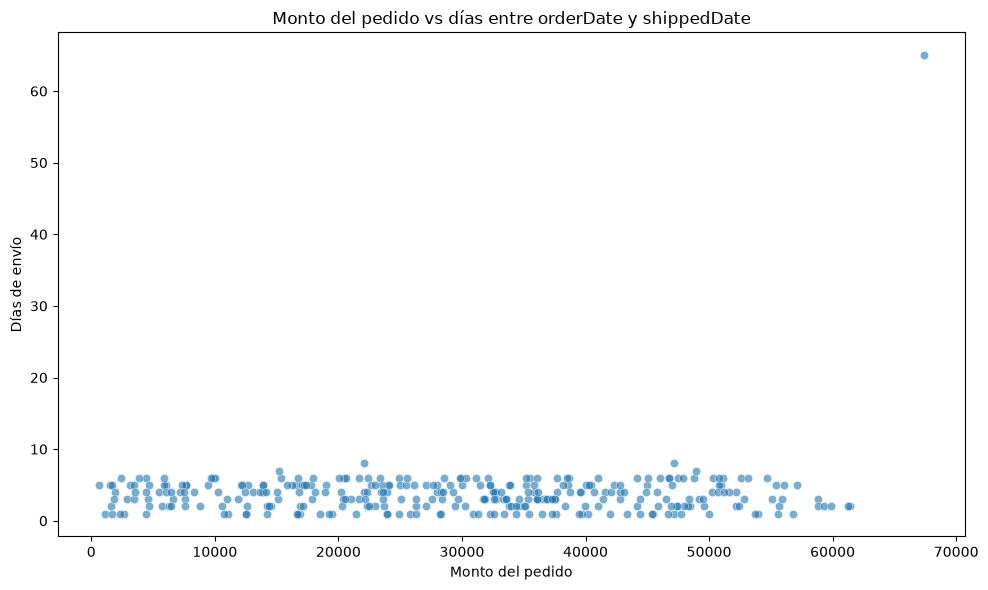

In [52]:
# Scatter: monto del pedido vs días de envío
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_biv2,
    x="monto_pedido",
    y="dias_envio",
    alpha=0.6,
)

plt.title("Monto del pedido vs días entre orderDate y shippedDate")
plt.xlabel("Monto del pedido")
plt.ylabel("Días de envío")
plt.tight_layout()
plt.show()

### Interpretación

- ¿Ves alguna tendencia (sube el monto y suben/bajan los días)?
- ¿Los puntos parecen una nube sin patrón claro?
- ¿La correlación cercana a 0, positiva o negativa te encaja con lo que ves?
- ¿Hay pedidos con monto muy alto o días muy altos que llamen la atención?

**Tu interpretación:**

> Claramente no hay ninguna relación aquí. Son como una nube sin patrón claro. La conclusión es que el tiempo que demora un pedido en ser enviado no tiene nada que ver con la cantidad de dinero que representa la compra. Sin embargo, hay un súper dato atípico que fue el que más dinero representaba y fue el que más días se demoró. Quizá tenga algo que ver, pero al ser un solo dato no podemos sacar conclusiones.


---

## Análisis bivariado 3

**Pregunta:** ¿Hay alguna relación entre el país del cliente y su límite de crédito?

**Variables:**
- `country` (categórica): país del cliente (`customers`)
- `creditLimit` (numérica): límite de crédito del cliente (`customers`)

**Gráfico:** boxplot (país vs `creditLimit`)

**Preparación:** usar `df_customers` directamente; no hace falta join. Revisar nulos en `creditLimit` si aparecen.

In [53]:
df_biv3 = df_customers[["customerNumber", "customerName", "country", "creditLimit"]].copy()
df_biv3["creditLimit"] = pd.to_numeric(df_biv3["creditLimit"], errors="coerce")

print("Clientes:", len(df_biv3))
print("Nulos en creditLimit:", df_biv3["creditLimit"].isna().sum())
print("Países distintos:", df_biv3["country"].nunique())
df_biv3.head(10)

Clientes: 122
Nulos en creditLimit: 0
Países distintos: 28


,customerNumber,customerName,country,creditLimit
0,103,Atelier graphique,France,21000.0
1,112,Signal Gift Stores,USA,71800.0
2,114,"Australian Collectors, Co.",Australia,117300.0
3,119,La Rochelle Gifts,France,118200.0
4,121,Baane Mini Imports,Norway,81700.0
5,124,Mini Gifts Distributors Ltd.,USA,210500.0
6,125,Havel & Zbyszek Co,Poland,0.0
7,128,"Blauer See Auto, Co.",Germany,59700.0
8,129,Mini Wheels Co.,USA,64600.0
9,131,Land of Toys Inc.,USA,114900.0


In [54]:
# Resumen por país (apoyo para interpretar)
resumen_credito = (
    df_biv3.groupby("country")["creditLimit"]
    .agg(clientes="count", mediana="median", promedio="mean", minimo="min", maximo="max")
    .sort_values("mediana")
)
resumen_credito

,clientes,mediana,promedio,minimo,maximo
country,,,,,
Netherlands,1,0.0,0.000000,0.0,0.0
Switzerland,3,0.0,47100.000000,0.0,141300.0
South Africa,1,0.0,0.000000,0.0,0.0
Russia,1,0.0,0.000000,0.0,0.0
Germany,13,0.0,19776.923077,0.0,120400.0
Israel,1,0.0,0.000000,0.0,0.0
Portugal,2,0.0,0.000000,0.0,0.0
Poland,1,0.0,0.000000,0.0,0.0
Ireland,2,34700.0,34700.000000,0.0,69400.0


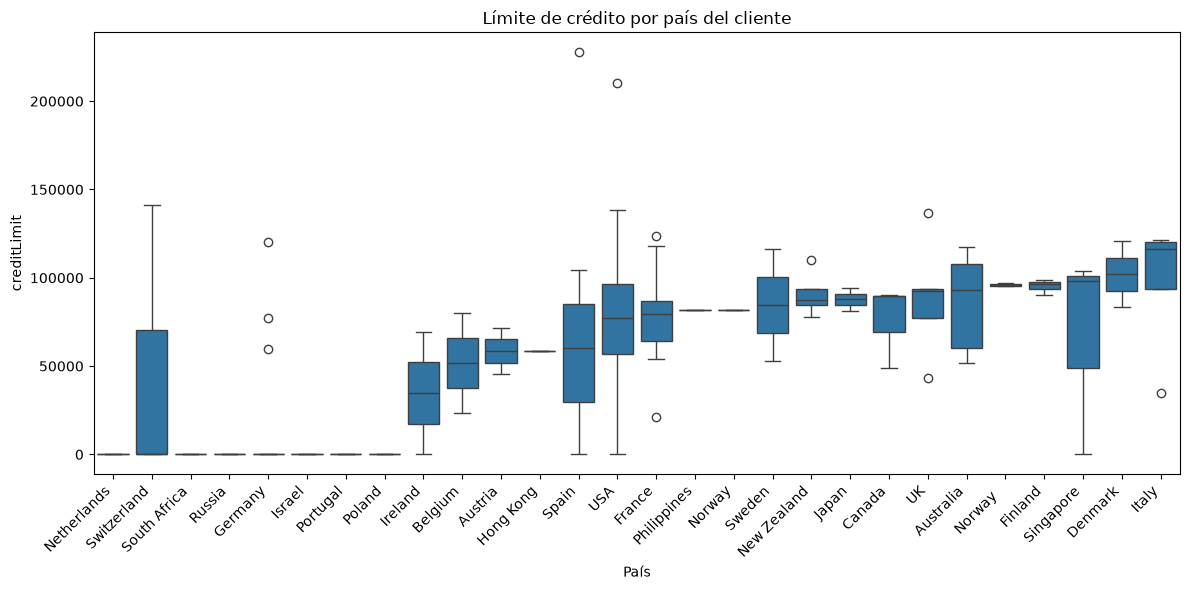

In [55]:
# Boxplot: creditLimit por país
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_biv3,
    x="country",
    y="creditLimit",
    order=resumen_credito.index.tolist(),
)

plt.title("Límite de crédito por país del cliente")
plt.xlabel("País")
plt.ylabel("creditLimit")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Interpretación (escríbela tú)

- ¿Las medianas de `creditLimit` cambian mucho entre países?
- ¿Hay países con créditos muy altos o muy bajos de forma consistente?
- ¿Hay cajas muy anchas (mucha dispersión dentro del mismo país)?
- ¿Países con pocos clientes limitan lo que puedes concluir?

**Tu interpretación:**

> Las medianas del límite del crédito claramente van cambiando dependiendo del pais. Vemos que hay unos paíes a los que no les quieren dar crédito como Netherlands, Switzerland, South Africa, Russia, Germany, entre otras. En total son 8 paises a los que no les suelen ofrecer crédito, lo que puede responder a pocos clientes o cuentas inactivas. Pero por ejemplo en Switzerland y en Germany sí hay clientes a los que les ofrecen un crédito considerable incluso superior a la media general, pero son contados y no represetan una buena proporción en su país. El resto de paises sí van variando de manera gradual, poco uniforme.

---

## Análisis bivariado 4

**Pregunta:** ¿Si hay más stock es porque se vende más el producto o porque se vende menos?

**Variables:**
- `quantityInStock` (numérica): inventario actual del producto (`products`)
- `cantidad_vendida` (numérica, calculada): suma de `quantityOrdered` por producto en `orderdetails`

**Gráfico:** scatter plot (stock vs cantidad vendida)

**Preparación:** agregar ventas por `productCode` en `orderdetails`, unir con `products`.  
**Nota:** el stock es una foto actual; las ventas son históricas. La relación puede existir, pero no prueba causalidad.

In [56]:
# Cantidad vendida histórica por producto
ventas_prod = (
    df_orderdetails.groupby("productCode", as_index=False)["quantityOrdered"]
    .sum()
    .rename(columns={"quantityOrdered": "cantidad_vendida"})
)

df_biv4 = pd.merge(
    df_products[["productCode", "productName", "productLine", "quantityInStock"]],
    ventas_prod,
    on="productCode",
    how="left",
)

# Productos sin ventas quedan en 0
df_biv4["cantidad_vendida"] = df_biv4["cantidad_vendida"].fillna(0)
df_biv4["quantityInStock"] = pd.to_numeric(df_biv4["quantityInStock"], errors="coerce")

print("Productos:", len(df_biv4))
df_biv4[["productCode", "productName", "quantityInStock", "cantidad_vendida"]].head(10)

Productos: 110


,productCode,productName,quantityInStock,cantidad_vendida
0,S10_1678,1969 Harley Davidson Ultimate Chopper,7933,1057.0
1,S10_1949,1952 Alpine Renault 1300,7305,961.0
2,S10_2016,1996 Moto Guzzi 1100i,6625,999.0
3,S10_4698,2003 Harley-Davidson Eagle Drag Bike,5582,985.0
4,S10_4757,1972 Alfa Romeo GTA,3252,1030.0
5,S10_4962,1962 LanciaA Delta 16V,6791,932.0
6,S12_1099,1968 Ford Mustang,68,933.0
7,S12_1108,2001 Ferrari Enzo,3619,1019.0
8,S12_1666,1958 Setra Bus,1579,972.0
9,S12_2823,2002 Suzuki XREO,9997,1028.0


In [57]:
# Resumen y correlación (apoyo; tú interpretas)
print(df_biv4[["quantityInStock", "cantidad_vendida"]].describe())
corr = df_biv4["quantityInStock"].corr(df_biv4["cantidad_vendida"])
print("\nCorrelación de Pearson (stock vs cantidad vendida):", round(corr, 4))

       quantityInStock  cantidad_vendida
count       110.000000        110.000000
mean       5046.645455        959.236364
std        2939.263668        137.381136
min          15.000000          0.000000
25%        2419.000000        917.000000
50%        5437.500000        962.000000
75%        7599.750000        997.750000
max        9997.000000       1808.000000

Correlación de Pearson (stock vs cantidad vendida): 0.0443


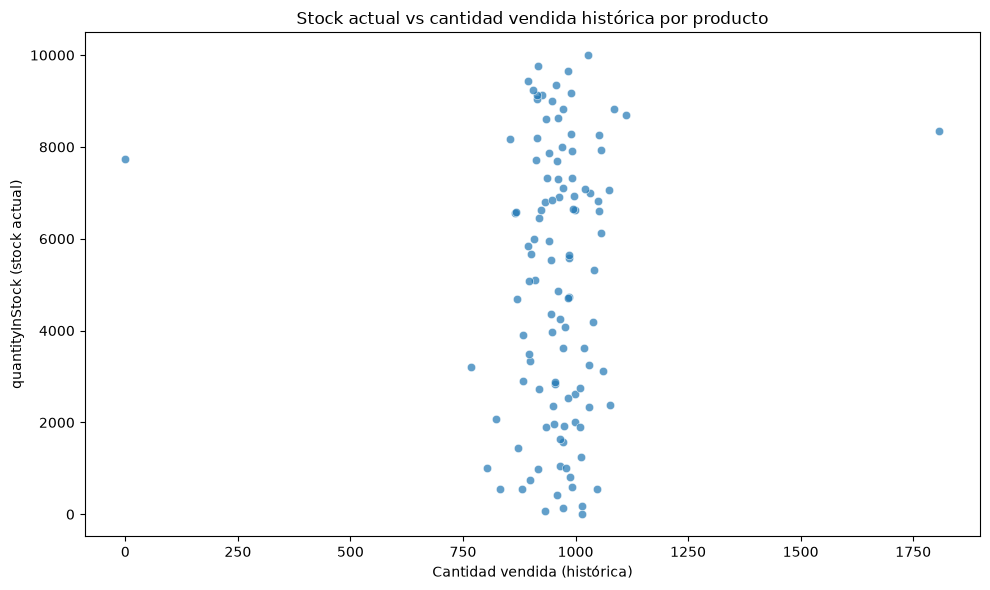

In [58]:
# Scatter: stock vs cantidad vendida
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_biv4,
    x="cantidad_vendida",
    y="quantityInStock",
    alpha=0.7,
)

plt.title("Stock actual vs cantidad vendida histórica por producto")
plt.xlabel("Cantidad vendida (histórica)")
plt.ylabel("quantityInStock (stock actual)")
plt.tight_layout()
plt.show()

### Interpretación

Pistas para responder tu pregunta:
- Si **más ventas ↔ más stock**: puntos hacia arriba a la derecha (relación positiva).
- Si **más ventas ↔ menos stock**: hacia abajo a la derecha (relación negativa: se agota el inventario).
- Si es una **nube**: no se ve un patrón claro; el stock actual no se explica solo por cuánto se vendió.

**Tu interpretación:**

> No se puede ver una relación directa entre la cantidad histórica vendida y la cantidad en stock. De hecho, se nota que casi todos los productos se han vendido entre 800 y 1100, pero están distribuidos de manera casi equitativa en su cantidad de stock, salvo por los extremos, que significaría un producto que no se ha vendido casi para nada y aún se tiene mucho stock y el producto estrella que es el que más se vende y coincide con su disponibilidad.


---

## Conclusiones generales

A partir de los cuatro análisis bivariados sobre ClassicModels:

1. **País × días de envío**  
   Parece quesí hay una asociación, hay unos países con envíos más rápidos y otros más lentos, entre estos últimos destacando Japón con una mediana claramente más alta.

2. **Monto del pedido × días de envío**  
   No se observa una relación clara. 

3. **País × límite de crédito**  
   Las medianas de `creditLimit` cambian según el país. Hay un grupo con mediana 0 pero algunos de ellos tienen clientes con crédito alto. En el otro resto de los países, la media varía de forma gradual.

4. **Stock actual × cantidad vendida histórica**  
   No se ve una relación directa. La mayoría de productos vende en un rango similar, de 800 a 1100, pero el stock se reparte de forma muy dispersa.

**Cierre:** de las cuatro preguntas, las relaciones más claras aparecen al cruzar **país** con variables de negocio (envío y crédito). Monto vs envío y stock vs ventas no muestran un patrón fuerte en estos datos. Toda interpretación debe tomarse como exploración descriptiva, no como causa-efecto.
